In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Object-Oriented Design for Implementation

Almost every model in this book follows the same loop: load data, run a forward
pass, compute the loss, update the parameters, and repeat. If we wrote that loop
from scratch for each new model, a small change to the training procedure (say,
adding gradient clipping or a learning-rate schedule) would force us to touch
every chapter. The fix, borrowed from libraries such as
[Lightning](https://lightning.ai/), is to write the loop once inside a reusable
`Trainer` class and let the model and the data vary as subclasses of `Module` and
`DataModule`:

* **`Module`** holds the model parameters, the `forward` pass, the loss, and the
  optimizer. Every model in the book is a subclass.
* **`DataModule`** holds a dataset and serves its training and validation data
  loaders. Every dataset is a subclass.
* **`Trainer`** owns the epoch loop: it feeds batches from the `DataModule` into
  the `Module` and applies the optimizer.

Most chapters subclass only `Module` and `DataModule`; we return to the `Trainer`
itself when we reach GPUs, parallel training, and optimization.
the figure shows how the three fit together.

![The three base classes and how they fit together. `Trainer.fit` drives a `Module` (which holds the model, loss, and optimizer) over data served by a `DataModule`; new models and datasets are written as subclasses.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-linreg-oo-classes.svg)

In [1]:
import time
import numpy as np
from d2l import tensorflow as d2l
import tensorflow as tf

## Utilities

We need a few utilities to simplify object-oriented programming in Jupyter notebooks. One of the challenges is that class definitions tend to be fairly long blocks of code. Notebook readability demands short code fragments, interspersed with explanations, a requirement incompatible with the style of programming common for Python libraries. The first
utility function allows us to register functions as methods in a class *after* the class has been created. In fact, we can do so *even after* we have created instances of the class! It allows us to split the implementation of a class into multiple code blocks.

In [2]:
def add_to_class(Class):
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
        return obj
    return wrapper

Let's have a quick look at how to use it. We plan to implement a class `A` with a method `do`. Instead of having code for both `A` and `do` in the same code block, we can first declare the class `A` and create an instance `a`.

In [3]:
class A:
    def __init__(self):
        self.b = 1

a = A()

Next we define the method `do` as we normally would, but not in class `A`'s scope. Instead, we decorate this method by `add_to_class` with class `A` as its argument. In doing so, the method is able to access the member variables of `A` just as we would expect had it been included as part of `A`'s definition. Let's see what happens when we invoke it for the instance `a`.

In [4]:
@add_to_class(A)
def do(self):
    print('Class attribute "b" is', self.b)

a.do()

Class attribute "b" is 1


The second one is a utility class that saves all arguments in a class's `__init__` method as class attributes. This allows us to extend constructor call signatures implicitly without additional code.

In [5]:
class HyperParameters:
    """The base class of hyperparameters."""
    def save_hyperparameters(self, ignore=None):
        raise NotImplementedError

The stub above fixes the *interface*; that section fills in the implementation on this same class, which is why saving even a `NotImplementedError` body with `#@save` is worthwhile. To use it, we define our class that inherits from `HyperParameters` and calls `save_hyperparameters` in the `__init__` method.

In [6]:
# Call the fully implemented HyperParameters class saved in d2l
class B(d2l.HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))

b = B(a=1, b=2, c=3)

self.a = 1 self.b = 2
There is no self.c = True


The final utility allows us to plot experiment progress interactively while it is going on. In deference to the much more powerful (and complex) [TensorBoard](https://www.tensorflow.org/tensorboard) we name it `ProgressBoard`. The  implementation is deferred to that section. For now, let's simply see it in action.

The `draw` method records a point `(x, y)` to be shown in the figure, with `label` specified in the legend. The optional `every_n` smooths the line: it shows one point per $n$ calls to `draw`, plotting the average of the last $n$ recorded values. As we explain just below, `draw` is *asynchronous*: it merely schedules the point and returns immediately, so that plotting never slows down training.

In [7]:
class ProgressBoard(d2l.HyperParameters):
    """The board that plots data points in animation."""
    def __init__(self, xlabel=None, ylabel=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 ls=['-', '--', '-.', ':'], colors=['C0', 'C1', 'C2', 'C3'],
                 fig=None, axes=None, figsize=(3.5, 2.5), display=True):
        self.save_hyperparameters()

    def draw(self, x, y, label, every_n=1):
        raise NotImplementedError

Why does `draw` go to the trouble of *scheduling* work instead of plotting
right away? The answer previews a theme that runs through the entire book.
Modern frameworks get their speed by *compiling* the training computation into a
graph that runs on the accelerator with little Python in the loop. Compilation
imposes two rules we must respect. First, a compiled step has to be *pure*: a
`print` or a plotting call inside it cannot be captured by the compiler, forcing a
fallback to slower eager execution. Second, the accelerator runs *asynchronously*,
ahead of Python; the instant we ask for a concrete number (to print or plot it),
Python must *block* until the device catches up, stalling the very pipeline we
worked to speed up.

Real-time monitoring therefore seems to be at odds with efficiency. `ProgressBoard`
resolves the tension by *decoupling* the two: `draw` hands the value to a queue and
returns at once, while a background thread performs the device-to-host transfer and
the (comparatively slow) rendering at its own pace, dropping points if it falls
behind, since a live loss curve needs no more than a few updates per second. The
training loop stays compiled and the device stays busy, yet we still watch the loss
go down as it happens. The pattern is general: keep the hot path pure and compiled,
and push logging, plotting, and checkpointing off to the side.

In the following example, we draw `sin` and `cos` with different smoothness. If you
run this code block interactively, you will see the lines grow in animation. Because
drawing is asynchronous, we finish with `board.flush()`, which waits for the queue
to drain and renders the final figure; `Trainer.fit` (developed below) does this for
you.

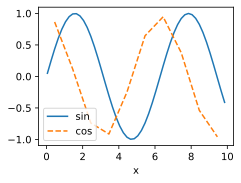

In [8]:
board = d2l.ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)
board.flush()  # wait for the queued points, then render the final figure

## Models

The `Module` class is the base class of all models we will implement. At the very least we need three methods. The first, `__init__`, stores the learnable parameters, the `training_step` method accepts a data batch to return the loss value, and finally, `configure_optimizers` returns the optimization method, or a list of them, that is used to update the learnable parameters. Optionally we can define `validation_step` to report the evaluation measures.
Sometimes we put the code for computing the output into a separate `forward` method to make it more reusable.
The `plot` method converts the trainer's batch
counter into a *fractional epoch* for the x-coordinate, so that the training
loss (recorded several times per epoch) and the validation loss (recorded once
per epoch) can share a single x-axis, with `every_n` chosen so each curve shows
a fixed number of points per epoch.

In [9]:
class Module(d2l.nn_Module, d2l.HyperParameters):
    """The base class of models."""
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        super().__init__()
        self.save_hyperparameters()
        self.board = ProgressBoard()
        self.training = None
        self.__dict__.pop('loss', None)

    def loss(self, y_hat, y):
        raise NotImplementedError

    def forward(self, X):
        assert hasattr(self, 'net'), 'Neural network is not defined'
        return self.net(X)

    def call(self, X, *args, training=None, **kwargs):
        if training is not None:
            self.training = training
        return self.forward(X, *args)

    def plot(self, key, value, train):
        """Plot a point in animation."""
        assert hasattr(self, 'trainer'), 'Trainer is not inited'
        self.board.xlabel = 'epoch'
        if train:
            x = self.trainer.train_batch_idx / \
                self.trainer.num_train_batches
            n = self.trainer.num_train_batches / \
                self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / \
                self.plot_valid_per_epoch
        # Defer the device-to-host transfer to the board's drawing thread.
        self.board.draw(x, lambda v=value: d2l.numpy(v), (
            'train_' if train else 'val_') + key, every_n=int(n))
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def _report_train(self, loss):
        self.plot('loss', loss, train=True)

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def _report_val(self, y_hat, batch):
        self.plot('loss', self.loss(y_hat, batch[-1]), train=False)

    def configure_optimizers(self):
        raise NotImplementedError

You may notice that `Module` is a subclass of `tf.keras.Model`, the base class of neural networks in TensorFlow.
It provides convenient features for handling neural networks. For example, it invokes the `call` method in the built-in `__call__` method. Here we redirect `call` to the `forward` method, saving its arguments as a class attribute, consistent with the `forward` convention used elsewhere in the book.
Note that in `__init__` we remove the `loss` instance attribute
that Keras 3 sets to `None`,
since it would shadow the `loss` method
defined by our subclasses.

##  Data

The `DataModule` class is the base class for data. Quite frequently the `__init__` method is used to prepare the data. This includes downloading and preprocessing if needed. The `train_dataloader` returns the data loader for the training dataset. A data loader is a (Python) generator that yields a data batch each time it is used. This batch is then fed into the `training_step` method of `Module` to compute the loss. There is an optional `val_dataloader` to return the validation dataset loader. It behaves in the same manner, except that it yields data batches for the `validation_step` method in `Module`.

In [10]:
class DataModule(d2l.HyperParameters):
    """The base class of data."""
    def __init__(self, root='../data', num_workers=4):
        self.save_hyperparameters()

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        return self.get_dataloader(train=False)

## Training
<!-- d2l:prose id=oo-design-md-13 fw=pytorch, mxnet, tensorflow -->

The `Trainer` class trains the learnable parameters in the `Module` class with data specified in `DataModule`. The key method is `fit`, which accepts two arguments: `model`, an instance of `Module`, and `data`, an instance of `DataModule`. It iterates over the entire dataset `max_epochs` times to train the model. Note that `fit_epoch` is left abstract here; it is implemented just two sections later, in that section.

In [11]:
class Trainer(d2l.HyperParameters):
    """The base class for training models with data."""
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        self.gpus = [d2l.gpu(i) for i in range(min(num_gpus, d2l.num_gpus()))]

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        self._compile_steps()
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()
        self.model.board.flush()  # drain queued points; render the final figure

    def fit_epoch(self):
        raise NotImplementedError

## Summary

The classes above sketch the object-oriented design
for our deep learning implementations: how their objects
store data and interact with each other.
We will keep enriching implementations of these classes,
such as via `@add_to_class`,
in the rest of the book.
Moreover,
these fully implemented classes
are saved in the [D2L library](https://github.com/d2l-ai/d2l-en/tree/master/d2l),
a *lightweight toolkit* that makes structured modeling for deep learning easy. 
In particular, it facilitates reusing many components between projects without changing much at all. This modularity keeps implementations concise: you can swap just the optimizer, the model, or the dataset, and it can do the same for your own projects. 


## Exercises

1. The `add_to_class` decorator works by calling `setattr(Class, obj.__name__, obj)`. (a) Add a method `greet(self)` to the existing class `A` *after* the instance `a` has been created, using `@add_to_class(A)`, and verify that `a.greet()` works. (b) What happens if you define `greet` *without* the decorator and then call `a.greet()`? Why?
1. The `Module` class keeps the optimizer in `configure_optimizers`, a *method of the model*, rather than passing it as an argument to `Trainer`. What are the advantages of this design choice? Can you think of a case where putting the optimizer on the model is awkward?
1. Extend `DataModule` with a `test_dataloader` method and extend `Trainer.fit` to run a final evaluation pass on the test set after training. What invariant must the test loader satisfy that the validation loader need not?
1. The `save_hyperparameters` implementation uses Python's `inspect` module to capture the caller's local variables. Can you implement a version that does *not* use `inspect`, for example by requiring the caller to pass the local namespace explicitly? What are the trade-offs?
1. (Advanced) The `ProgressBoard.draw` method is *asynchronous*: it hands values to a background thread rather than plotting immediately. Sketch a synchronous alternative. Under what conditions would the synchronous version be slower? When would the two perform identically?
1. Remove the `save_hyperparameters` statement in the `B` class. Can you still print `self.a` and `self.b`? Optional: if you have studied the full implementation of the `HyperParameters` class, can you explain why?

[Discussions](https://d2l.discourse.group/t/6647)